## (a) Creating the mpg01 Binary Variable
The variable `mpg01` equals:
- 1 if a car's MPG is above the median
- 0 otherwise

In [5]:
import pandas as pd

auto = pd.read_csv("Auto.csv")

mpg_median = auto['mpg'].median()

auto['mpg01'] = (auto['mpg'] > mpg_median).astype(int)

auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0


## (b) Exploring Associations Between mpg01 and Other Features
We create boxplots and scatterplots to determine which variables best 
separate high-MPG (mpg01 = 1) and low-MPG (mpg01 = 0) cars.

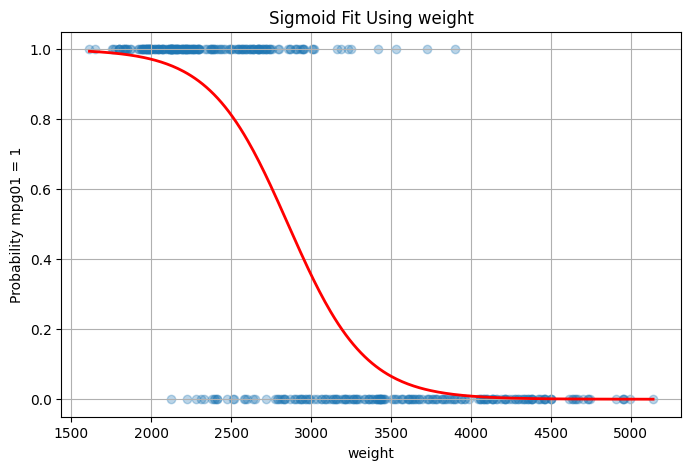

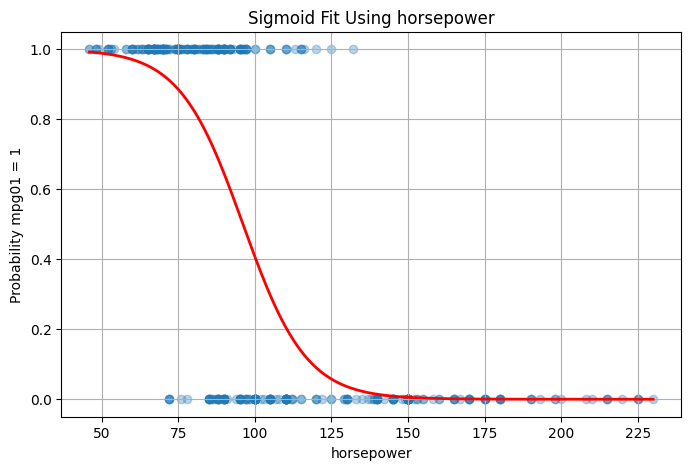

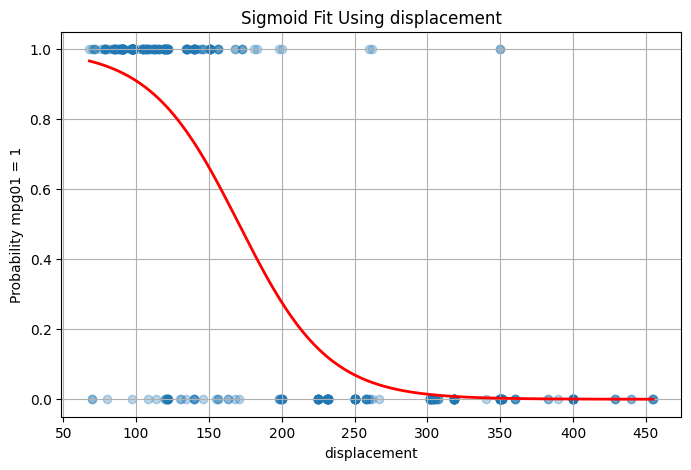

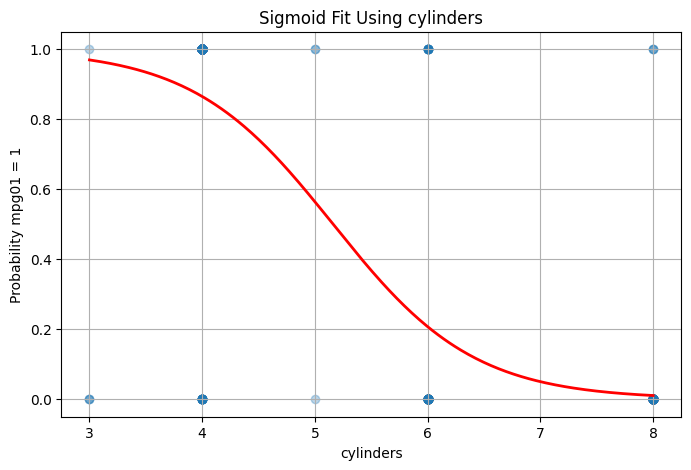

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load dataset
auto = pd.read_csv("Auto.csv")

# Clean horsepower (may contain '?')
auto = auto.replace("?", np.nan)
auto = auto.dropna()
auto["horsepower"] = auto["horsepower"].astype(float)

# Create mpg01
mpg_median = auto["mpg"].median()
auto["mpg01"] = (auto["mpg"] > mpg_median).astype(int)

# Variables to plot
predictors = ["weight", "horsepower", "displacement", "cylinders"]

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loop through variables
for feature in predictors:
    X = auto[[feature]]
    y = auto["mpg01"]

    # Fit logistic regression
    model = LogisticRegression()
    model.fit(X, y)

    # Smooth range
    x_range = np.linspace(X[feature].min(), X[feature].max(), 300)
    linear_pred = model.coef_[0][0] * x_range + model.intercept_[0]
    sigmoid_pred = sigmoid(linear_pred)

    # Plot
    plt.figure(figsize=(8,5))
    plt.scatter(X[feature], y, alpha=0.3)
    plt.plot(x_range, sigmoid_pred, color="red", linewidth=2)
    plt.xlabel(feature)
    plt.ylabel("Probability mpg01 = 1")
    plt.title(f"Sigmoid Fit Using {feature}")
    plt.grid(True)
    plt.show()

## 📌 Conclusion

In this analysis, we created a binary variable mpg01 to distinguish high–MPG cars from low–MPG cars based on the median MPG value. After exploring the Auto dataset graphically, we identified weight, horsepower, displacement, and cylinders as the variables most strongly associated with fuel efficiency. These features showed clear visual separation between high and low MPG cars using both boxplots and scatterplots.

To further investigate these relationships, we fit logistic regression models using each predictor individually and plotted the resulting sigmoid curves. The sigmoid function models the probability that a car belongs to the high-MPG class (mpg01 = 1) as the predictor increases. Across all four predictors, the logistic curves showed a strong negative relationship: as weight, horsepower, displacement, or cylinder count increases, the probability of achieving high MPG decreases.

These results confirm the intuitive understanding that lighter, smaller-engine, lower-power cars are far more fuel-efficient than heavier, high-displacement vehicles. The sigmoid plots effectively illustrate how each predictor influences the probability of high MPG, and they will be essential for comparison with LDA, QDA, Naive Bayes, and KNN models in later parts of the assignment.